# 01 Video Data Exploration

Analyze the DFDC video dataset structure, dynamically discover available parts, and visualize class distribution.

### Key Goals:
- **Path Stability**: Use `PROJECT_ROOT` to resolve all paths from the project base.
- **Dynamic Discovery**: Scan for all `dfdc_train_part_*` folders using hardened logic.
- **Metadata Analysis**: Load `metadata.json` from each part to map labels.

In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import yaml
import json
import logging

# --- PROJECT ROOT ---
PROJECT_ROOT = Path().resolve().parents[1]
print(f"Project Root: {PROJECT_ROOT}")

# --- CONFIG ---
CONFIG_PATH = PROJECT_ROOT / "configs" / "video_config.yaml"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config file not found at: {CONFIG_PATH}")

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

DATA_PATH = PROJECT_ROOT / config["data"]["raw_path"]
print(f"Resolved DATA_PATH: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATA_PATH}")

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

Project Root: D:\Projects\Machine_Learning Projects\Cognito_AI_A.M
Resolved DATA_PATH: D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos


## 1. Hardened Dataset Discovery

In [2]:
def extract_part_number(name):
    try:
        return int(name.split('_')[-1].strip())
    except:
        return None


def discover_dataset_paths(base_path, max_part=4):  # 🔥 LIMIT HERE
    base_path = Path(base_path)

    if not base_path.exists():
        print(f"Error: Base path {base_path} does not exist.")
        return []

    valid_parts = []

    for item in os.listdir(base_path):
        item_path = base_path / item

        if item.startswith("dfdc_train_part_") and item_path.is_dir():
            part_num = extract_part_number(item)

            if part_num is not None and part_num <= max_part:  # 🔥 FILTER
                valid_parts.append((item_path, part_num))

    if not valid_parts:
        print("No valid dataset parts found.")
        return []

    valid_parts.sort(key=lambda x: x[1])

    part_numbers = [x[1] for x in valid_parts]

    print(f"[INFO] Using parts: {part_numbers}")

    final_paths = []

    for path, num in valid_parts:
        if (path / "metadata.json").exists():
            final_paths.append(path)
        else:
            print(f"[WARNING] Skipping {path.name} (no metadata.json)")

    return final_paths


parts = discover_dataset_paths(DATA_PATH, max_part=4)

print("\nValidated Dataset Paths:")
for p in parts:
    print(f" - {p}")

[INFO] Using parts: [0, 1, 2, 3, 4]

Validated Dataset Paths:
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_0
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_1
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_2
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_3
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_4


## 2. Collect Metadata & Labels

In [3]:
def collect_video_info(parts_paths):
    data = []

    for part_path in tqdm(parts_paths, desc="Scanning Parts"):
        metadata_path = part_path / "metadata.json"

        try:
            with open(metadata_path, "r") as f:
                metadata = json.load(f)
        except:
            print(f"[WARNING] Failed to load {metadata_path}")
            continue

        for filename, info in metadata.items():
            video_path = part_path / filename

            if video_path.exists():
                data.append({
                    "path": str(video_path),
                    "part": part_path.name,
                    "label": info["label"],
                    "label_id": 1 if info["label"] == "FAKE" else 0
                })

    return pd.DataFrame(data)


if parts:
    df = collect_video_info(parts)
    print(f"[INFO] Total videos discovered: {len(df)}")
    display(df.head())
else:
    print("No parts found.")

Scanning Parts:   0%|          | 0/5 [00:00<?, ?it/s]

[INFO] Total videos discovered: 7937


,path,part,label,label_id
0,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,FAKE,1
1,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,REAL,0
2,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,REAL,0
3,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,FAKE,1
4,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,FAKE,1


## 3. Analyze Distribution

Class Distribution:
label
FAKE    7111
REAL     826
Name: count, dtype: int64


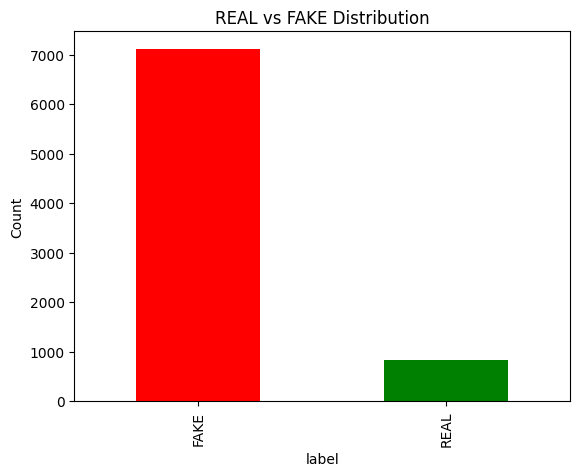

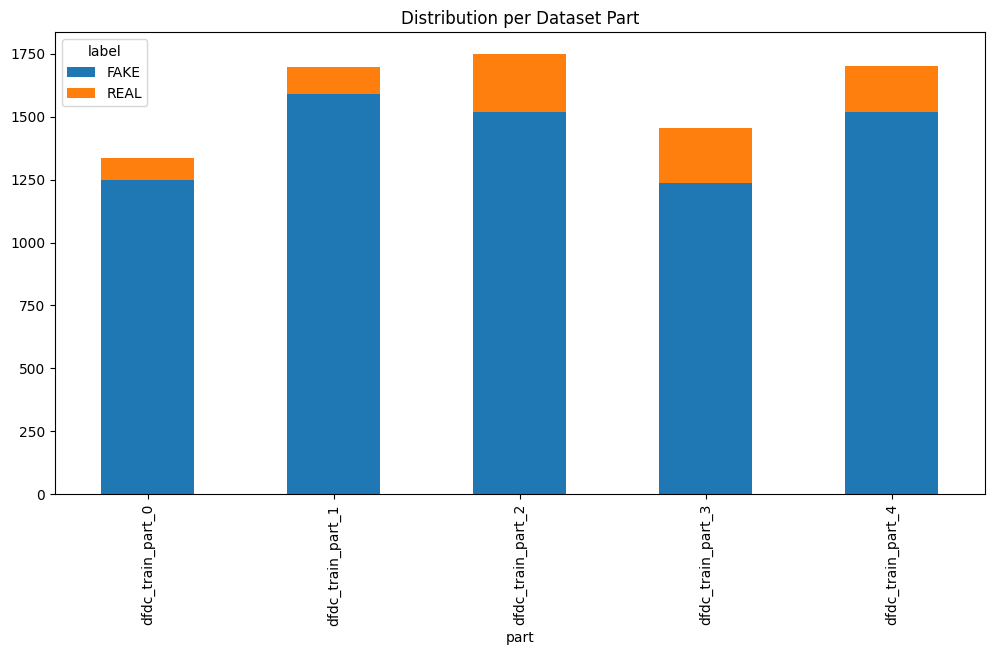

In [4]:
if 'df' in locals() and not df.empty:
    dist = df["label"].value_counts()

    print("Class Distribution:")
    print(dist)

    dist.plot(kind="bar", color=['red', 'green'])
    plt.title("REAL vs FAKE Distribution")
    plt.ylabel("Count")
    plt.show()

    # per-part distribution
    part_dist = df.groupby(["part", "label"]).size().unstack(fill_value=0)

    part_dist.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title("Distribution per Dataset Part")
    plt.show()

else:
    print("No data to analyze.")